## C-V Characteristic Modeling

1. import

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


from phis_init import phi_init


from CVModeling import (
    G_phigd,
    Cjfet,
    Cgd,
    Cds,
    Cds_no_PT,
    Cgs,
)


device = "cpu"

dtype = torch.float32

2. Parameters

In [3]:
# ============================================================
# Surface-potential model parameters
# ============================================================

T = 300.0


# P-body acceptor concentration
NA = 1.0e16


# Drift-region donor concentration
ND = 5.0e16


# 4H-SiC bandgap
Eg = 3.26


# Absolute permittivity of 4H-SiC
eps_sic = (
    9.26
    * 8.854e-14
)


# Oxide capacitance per unit area
Cox = 7.0e-8


# Flat-band voltage
Vfbs0 = -1.0


# Interface-trap parameters
Dit_mid = 2.0e11

Dit_edge = 2.0e13

sigma_it = 0.1


# ============================================================
# Geometry
#
# Agd = 3.15 mm^2 = 0.0315 cm^2
# Ads = 2.97 mm^2 = 0.0297 cm^2
# ============================================================

Agd = 3.15e-2

Ads = 2.97e-2


# ============================================================
# C-V parameters
# ============================================================

Vbi = 2.8

Vpt = 500.0


# Gate-drain oxide capacitance
Coxgd = (
    Cox
    * Agd
)


# Constant gate-source capacitance
Cgs_const = 1200e-12

Add: PINN Network Duplication

In [ ]:
# ============================================================
# Surface-potential PINN
#
# IMPORTANT:
# This class must be EXACTLY the same as the class used
# to train phis_PINN.pth in PINN_phis.ipynb.
#
# Architecture:
#
# [Vgs, Vds]
#      ↓
# Linear(2, 8)
#      ↓
# Tanh
#      ↓
# Linear(8, 1)
#      ↓
# delta_phi_s
# ============================================================

class DeltaPhisPINN(
    nn.Module
):

    def __init__(
        self
    ):

        super().__init__()


        # ====================================================
        # Neural network
        # ====================================================

        self.net = nn.Sequential(

            nn.Linear(
                2,
                8
            ),

            nn.Tanh(),

            nn.Linear(
                8,
                1
            )
        )


        # ====================================================
        # Same initialization as original training notebook
        #
        # This initialization is overwritten after loading
        # phis_PINN.pth, but keeping it makes the class
        # identical to the original one.
        # ====================================================

        nn.init.zeros_(
            self.net[2].weight
        )

        nn.init.zeros_(
            self.net[2].bias
        )


    def forward(
        self,
        Vgs,
        Vds,
    ):

        # ====================================================
        # Ensure column-vector shape
        # ====================================================

        Vgs = Vgs.reshape(
            -1,
            1
        )

        Vds = Vds.reshape(
            -1,
            1
        )


        # ====================================================
        # Network input
        #
        # IMPORTANT:
        # Original PINN does NOT normalize the inputs.
        # ====================================================

        x = torch.cat(
            [
                Vgs,
                Vds
            ],
            dim=1
        )


        # ====================================================
        # Direct neural-network correction
        #
        # IMPORTANT:
        #
        # Original PINN does NOT use:
        #
        # 5 * tanh(...)
        #
        # here.
        # ====================================================

        delta_phis = self.net(
            x
        )


        return delta_phis

Add: Load training results

In [5]:
# ============================================================
# Load trained surface-potential PINN
# ============================================================


# ============================================================
# Create the SAME model architecture used during training
# ============================================================

Model = DeltaPhisPINN().to(
    device=device,
    dtype=dtype,
)


# ============================================================
# Path of trained model
# ============================================================

MODEL_PATH = (
    "phis_PINN.pth"
)


# ============================================================
# Load state dictionary
# ============================================================

state_dict = torch.load(
    MODEL_PATH,
    map_location=device,
)


# ============================================================
# Check checkpoint architecture
# ============================================================

print(
    "Checkpoint structure:"
)

for key, value in state_dict.items():

    print(
        key,
        tuple(value.shape)
    )


# ============================================================
# Load trained weights
# ============================================================

Model.load_state_dict(
    state_dict,
    strict=True,
)


Model.eval()


print(
    "\nSurface-potential PINN "
    "loaded successfully."
)

Checkpoint structure:
net.0.weight (8, 2)
net.0.bias (8,)
net.2.weight (1, 8)
net.2.bias (1,)

Surface-potential PINN loaded successfully.


3. C-V Voltage Sweep definition

In [6]:
# ============================================================
# C-V voltage sweep
# ============================================================

N_CV = 1001


Vds_cv = torch.linspace(
    0.0,
    1000.0,
    N_CV,
    dtype=dtype,
    device=device,
).reshape(
    -1,
    1
)


# Fixed gate voltage
VGS_CV = 0.0


Vgs_cv = torch.full_like(
    Vds_cv,
    VGS_CV,
)

4. PT clamp for Cgd

In [7]:
# ============================================================
# Drain-gate voltage
#
# Vdg = Vds - Vgs
# ============================================================

Vdg_cv = (
    Vds_cv
    - Vgs_cv
)


# ============================================================
# Punch-through
#
# If:
#
# Vdg > Vpt
#
# clamp:
#
# Vdg = Vpt
# ============================================================

Vdg_eff = torch.clamp(
    Vdg_cv,
    min=0.0,
    max=Vpt,
)


# ============================================================
# Convert to gate-drain voltage
#
# Vgd = -Vdg
#
# because here Vgs = 0
# ============================================================

Vgd_eff = (
    -Vdg_eff
)


# ============================================================
# Corresponding effective Vds
# ============================================================

Vds_eff = torch.clamp(
    Vds_cv,
    min=0.0,
    max=Vpt,
)


print(
    "Vgd_eff shape =",
    Vgd_eff.shape
)

print(
    "Vds_eff shape =",
    Vds_eff.shape
)

Vgd_eff shape = torch.Size([1001, 1])
Vds_eff shape = torch.Size([1001, 1])


In [8]:
# ============================================================
# Surface-potential prediction
# ============================================================

@torch.no_grad()
def predict_phis(
    model,
    V_control,
    phi_f,
):

    model.eval()


    # --------------------------------------------------------
    # Input tensors
    # --------------------------------------------------------

    V_control = torch.as_tensor(
        V_control,
        dtype=dtype,
        device=device,
    ).reshape(
        -1,
        1
    )


    phi_f = torch.as_tensor(
        phi_f,
        dtype=dtype,
        device=device,
    ).reshape(
        -1,
        1
    )


    # --------------------------------------------------------
    # Analytical initial surface potential
    # --------------------------------------------------------

    phi_init_value = phi_init(
        V_control,
        phi_f,
        T,
        NA,
        eps_sic,
        Cox,
        Vfbs0,
        Dit_mid,
        Dit_edge,
        sigma_it,
        Eg,
    ).reshape(
        -1,
        1
    )


    # --------------------------------------------------------
    # PINN correction
    # --------------------------------------------------------

    delta_phi = model(
        V_control,
        phi_f,
    )


    # --------------------------------------------------------
    # Final surface potential
    # --------------------------------------------------------

    phi_s = (
        phi_init_value
        + delta_phi
    )


    return phi_s


# ============================================================
# Obtain phi_gd
#
# Paper:
#
# replace Vgs with Vgd
#
# phi_f = Vds
# ============================================================

phi_gd = predict_phis(
    Model,
    Vgd_eff,
    Vds_eff,
)


print(
    "phi_gd shape =",
    phi_gd.shape
)


print(
    "phi_gd range =",
    phi_gd.min().item(),
    "to",
    phi_gd.max().item(),
    "V"
)

phi_gd shape = torch.Size([1001, 1])
phi_gd range = -0.26687729358673096 to 0.7107047438621521 V


In [9]:
print(
    "Vds(V)      "
    "Vgd_eff(V)      "
    "phi_gd(V)"
)

print("-" * 60)


for V in [
    0.0,
    1.0,
    5.0,
    10.0,
    20.0,
    50.0,
    100.0,
    200.0,
    500.0,
]:

    idx = torch.argmin(
        torch.abs(
            Vds_cv.flatten()
            - V
        )
    )

    print(
        f"{V:7.1f}      "
        f"{Vgd_eff[idx].item(): .6e}      "
        f"{phi_gd[idx].item(): .6e}"
    )

Vds(V)      Vgd_eff(V)      phi_gd(V)
------------------------------------------------------------
    0.0      -0.000000e+00       7.107047e-01
    1.0      -1.000000e+00       1.292960e-01
    5.0      -5.000000e+00      -1.124722e-02
   10.0      -1.000000e+01      -5.274272e-02
   20.0      -2.000000e+01      -9.735845e-02
   50.0      -5.000000e+01      -1.469513e-01
  100.0      -1.000000e+02      -1.832656e-01
  200.0      -2.000000e+02      -2.193468e-01
  500.0      -5.000000e+02      -2.668773e-01


Calculate G(ϕgd) and CJFET, Cgd, Cds

In [10]:
# ============================================================
# C-V characteristic calculation
# ============================================================

with torch.no_grad():


    # ========================================================
    # Eq. (24)
    # ========================================================

    G_gd = G_phigd(
        phi_gd,
        Vds_eff,
        T,
        NA,
        Eg,
    )


    # ========================================================
    # Eq. (23)
    # ========================================================

    CJFET = Cjfet(
        phi_gd,
        Vds_eff,
        T,
        NA,
        ND,
        Eg,
        eps_sic,
        Agd,
    )


    # ========================================================
    # Eq. (22)
    # ========================================================

    Cgd_value = Cgd(
        phi_gd,
        Vds_eff,
        T,
        NA,
        ND,
        Eg,
        eps_sic,
        Agd,
        Coxgd,
    )


    # ========================================================
    # Eq. (25)
    # ========================================================

    Cds_value = Cds(
        Vds_cv,
        ND,
        eps_sic,
        Ads,
        Vbi,
        Vpt,
    )


    # ========================================================
    # Cgs = constant
    # ========================================================

    Cgs_value = Cgs(
        Vds_cv,
        Cgs_const,
    )

F to pF

In [11]:
# ============================================================
# F -> pF
# ============================================================

CJFET_pF = (
    CJFET
    * 1e12
)


Cgd_pF = (
    Cgd_value
    * 1e12
)


Cds_pF = (
    Cds_value
    * 1e12
)


Cgs_pF = (
    Cgs_value
    * 1e12
)

Print representative values

In [12]:
# ============================================================
# Representative values
# ============================================================

test_voltages = [
    0.0,
    1.0,
    5.0,
    10.0,
    20.0,
    50.0,
    100.0,
    200.0,
    500.0,
    800.0,
    1000.0,
]


print(
    "Vds(V)      "
    "phi_gd(V)      "
    "CJFET(pF)      "
    "Cgd(pF)      "
    "Cds(pF)      "
    "Cgs(pF)"
)


print(
    "-" * 100
)


for V in test_voltages:

    idx = torch.argmin(
        torch.abs(
            Vds_cv.flatten()
            - V
        )
    )


    print(
        f"{V:7.1f}      "
        f"{phi_gd[idx].item(): .6e}      "
        f"{CJFET_pF[idx].item(): .6e}      "
        f"{Cgd_pF[idx].item(): .6e}      "
        f"{Cds_pF[idx].item(): .6e}      "
        f"{Cgs_pF[idx].item(): .6e}"
    )

Vds(V)      phi_gd(V)      CJFET(pF)      Cgd(pF)      Cds(pF)      Cgs(pF)
----------------------------------------------------------------------------------------------------
    0.0       7.107047e-01       2.181285e+03       1.096539e+03       1.017133e+03       1.200000e+03
    1.0       1.292960e-01       5.570081e+03       1.579666e+03       8.731022e+02       1.200000e+03
    5.0      -1.124722e-02      -1.845088e+04       2.504277e+03       6.094100e+02       1.200000e+03
   10.0      -5.274272e-02      -3.483439e+04       2.354007e+03       4.757205e+02       1.200000e+03
   20.0      -9.735845e-02      -7.642741e+04       2.270506e+03       3.564425e+02       1.200000e+03
   50.0      -1.469513e-01      -1.941386e+05       2.230332e+03       2.342286e+02       1.200000e+03
  100.0      -1.832656e-01      -3.897041e+05       2.217547e+03       1.678651e+02       1.200000e+03
  200.0      -2.193468e-01      -7.816854e+05       2.211238e+03       1.195151e+02       1.200000e+03

10. Plot

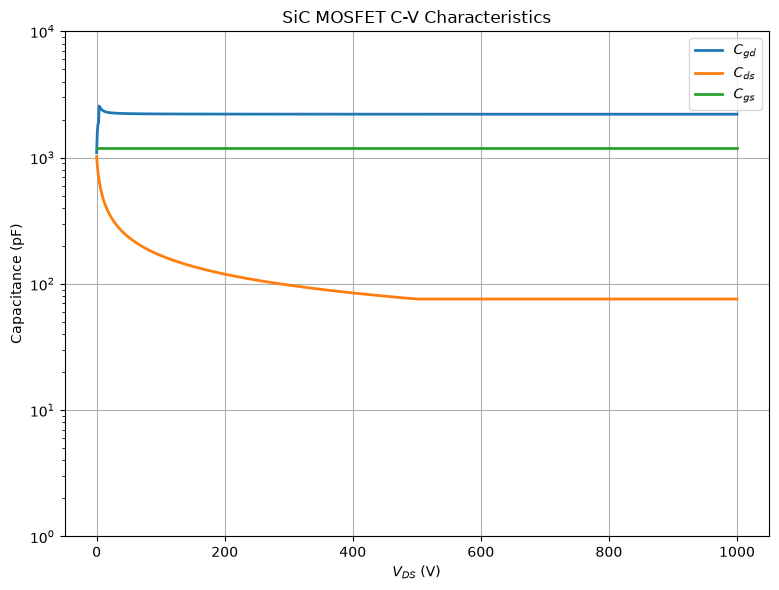

In [13]:
# ============================================================
# Plot C-V characteristics
# ============================================================

plt.figure(
    figsize=(8, 6)
)


plt.plot(
    Vds_cv.cpu().numpy(),
    Cgd_pF.cpu().numpy(),
    label=r"$C_{gd}$",
    linewidth=2,
)


plt.plot(
    Vds_cv.cpu().numpy(),
    Cds_pF.cpu().numpy(),
    label=r"$C_{ds}$",
    linewidth=2,
)


plt.plot(
    Vds_cv.cpu().numpy(),
    Cgs_pF.cpu().numpy(),
    label=r"$C_{gs}$",
    linewidth=2,
)


plt.xlabel(
    r"$V_{DS}$ (V)"
)


plt.ylabel(
    "Capacitance (pF)"
)


plt.title(
    "SiC MOSFET C-V Characteristics"
)


plt.grid(
    True
)


plt.legend()


plt.tight_layout()
plt.yscale("log")
plt.ylim(1, 1e4)

plt.show()